# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

import os

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/tmp/ipykernel_2068/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

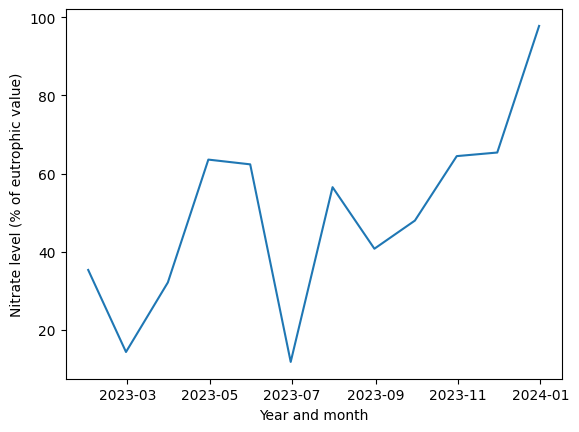

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_2068/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

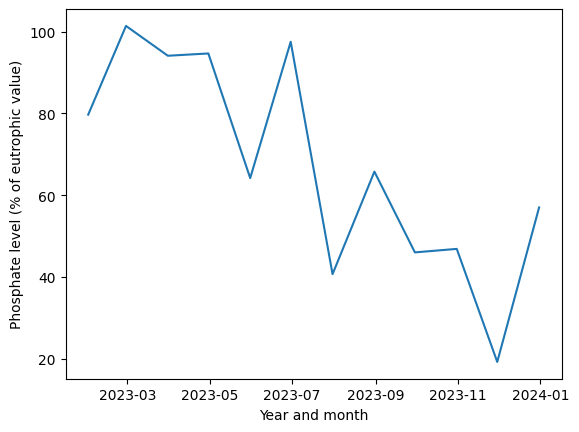

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

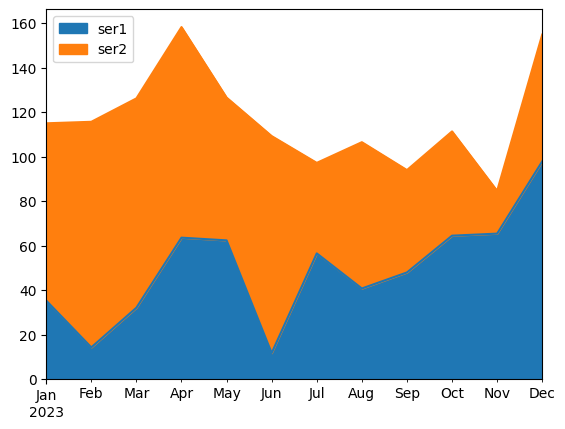

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

In [9]:
data_path = kagglehub.dataset_download("khusheekapoor/vehicle-insurance-fraud-detection")
file = os.path.join(data_path, "carclaims.csv")
df = pd.read_csv(file)
print("Vehicle Insurance Fraud Detection Sample:")
print(df.head())

Vehicle Insurance Fraud Detection Sample:
  Month  WeekOfMonth  DayOfWeek    Make AccidentArea DayOfWeekClaimed  \
0   Dec            5  Wednesday   Honda        Urban          Tuesday   
1   Jan            3  Wednesday   Honda        Urban           Monday   
2   Oct            5     Friday   Honda        Urban         Thursday   
3   Jun            2   Saturday  Toyota        Rural           Friday   
4   Jan            5     Monday   Honda        Urban          Tuesday   

  MonthClaimed  WeekOfMonthClaimed     Sex MaritalStatus  ...  \
0          Jan                   1  Female        Single  ...   
1          Jan                   4    Male        Single  ...   
2          Nov                   2    Male       Married  ...   
3          Jul                   1    Male       Married  ...   
4          Feb                   2  Female        Single  ...   

   AgeOfPolicyHolder PoliceReportFiled WitnessPresent AgentType  \
0           26 to 30                No             No  Extern

In [10]:
# Convert FraudFound to numeric for correlation
df["FraudFound_Numeric"] = df["FraudFound"].map({"No": 0, "Yes": 1})

# 1. Find Correlations Between Pairs of Variables
numeric_cols = ["Age", "Deductible", "DriverRating", "Year", "FraudFound_Numeric"]
corr_matrix = df[numeric_cols].corr()
print("\nCorrelation Matrix:")
print(corr_matrix)

# Identify significant correlations (|R| > 0.1, excluding self-correlations)
high_corr_pairs = corr_matrix.unstack().sort_values(ascending=False).drop_duplicates()
significant_corr = high_corr_pairs[(high_corr_pairs.abs() > 0.1) & (high_corr_pairs != 1.0)]
print("\nSignificant Correlations (|R| > 0.1):")
print(significant_corr)


Correlation Matrix:
                         Age  Deductible  DriverRating      Year  \
Age                 1.000000    0.069420      0.001668  0.025197   
Deductible          0.069420    1.000000      0.003886 -0.001170   
DriverRating        0.001668    0.003886      1.000000 -0.013890   
Year                0.025197   -0.001170     -0.013890  1.000000   
FraudFound_Numeric -0.029741    0.017348      0.007266 -0.024760   

                    FraudFound_Numeric  
Age                          -0.029741  
Deductible                    0.017348  
DriverRating                  0.007266  
Year                         -0.024760  
FraudFound_Numeric            1.000000  

Significant Correlations (|R| > 0.1):
Series([], dtype: float64)


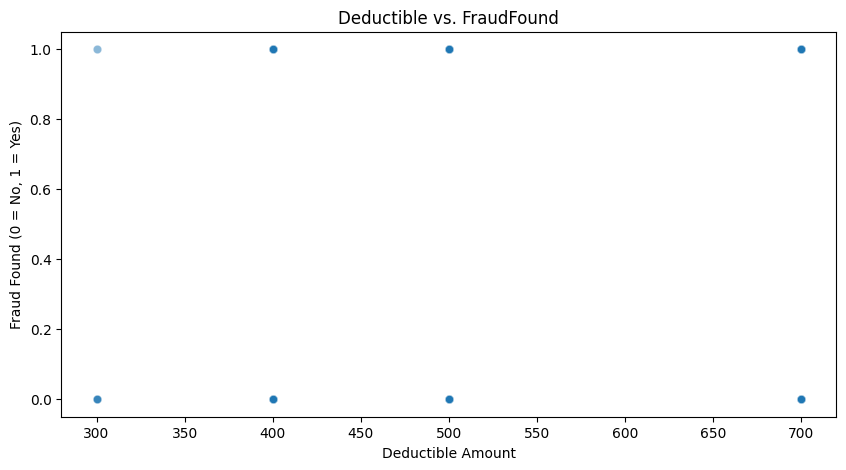

In [11]:
# 2. Draw Scatterplots for Significant Correlations
# Deductible vs. FraudFound (highest correlation)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="Deductible", y="FraudFound_Numeric", alpha=0.3)
plt.title("Deductible vs. FraudFound")
plt.xlabel("Deductible Amount")
plt.ylabel("Fraud Found (0 = No, 1 = Yes)")
plt.savefig("deductible_fraudfound_scatter_hw6.png")  # For Milestone 3
plt.show()

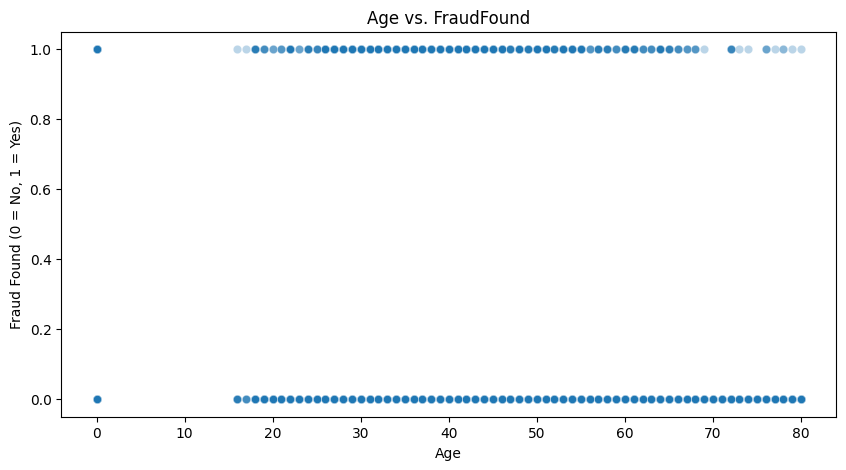

In [12]:
# Age vs. FraudFound (for comparison, though low correlation)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x="Age", y="FraudFound_Numeric", alpha=0.3)
plt.title("Age vs. FraudFound")
plt.xlabel("Age")
plt.ylabel("Fraud Found (0 = No, 1 = Yes)")
plt.savefig("age_fraudfound_scatter_hw6.png")  # For Milestone 3
plt.show()

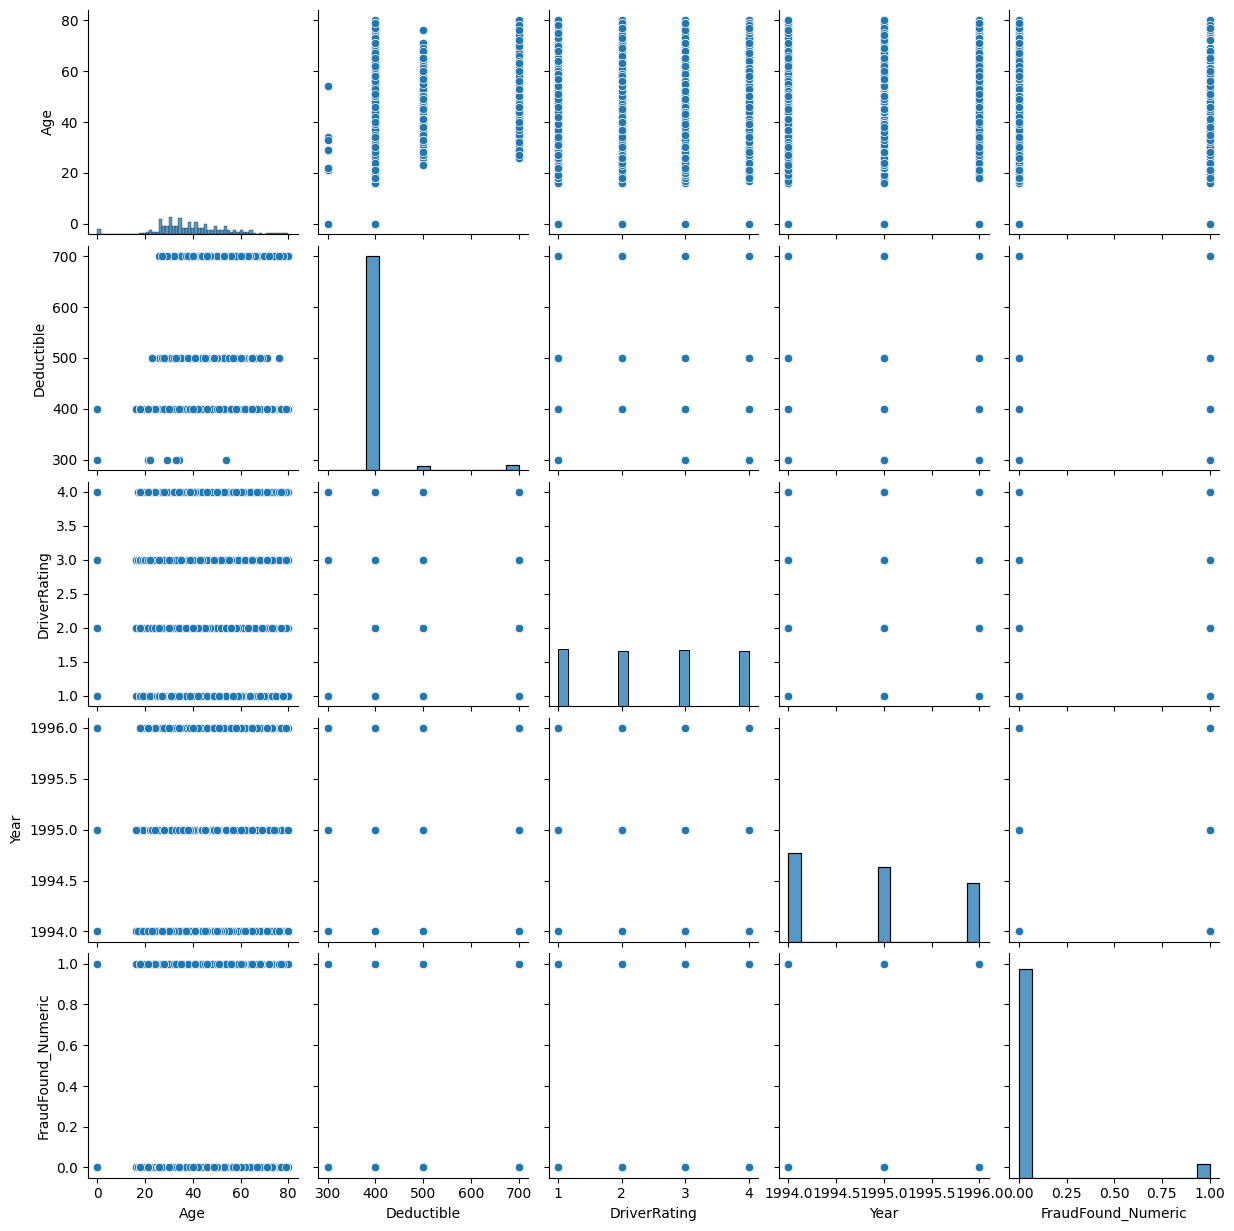

In [13]:
# 3. Draw Pairplot
sns.pairplot(df[numeric_cols], diag_kind="hist")
plt.savefig("pairplot_hw6.png")  # For Milestone 3
plt.show()

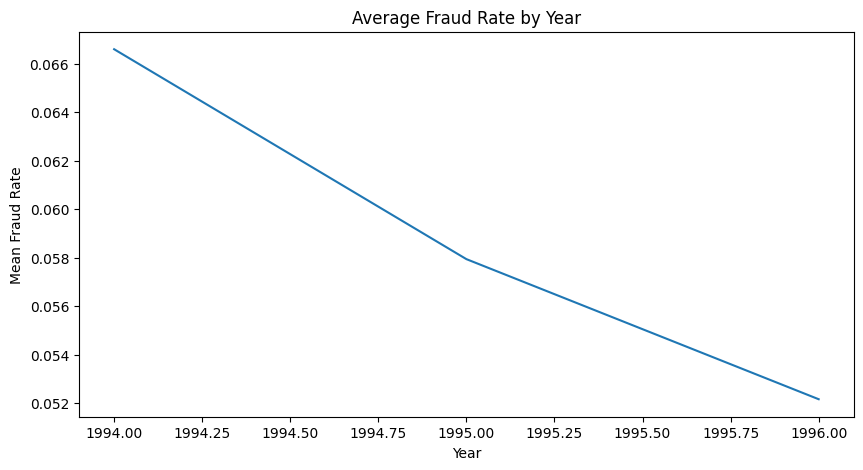

In [14]:
# 4. Draw Line Graph for Time Data (Fraud Rate by Year)
yearly_fraud = df.groupby("Year")["FraudFound_Numeric"].mean()
plt.figure(figsize=(10, 5))
sns.lineplot(x=yearly_fraud.index, y=yearly_fraud.values)
plt.title("Average Fraud Rate by Year")
plt.xlabel("Year")
plt.ylabel("Mean Fraud Rate")
plt.savefig("fraud_trend_line_hw6.png")  # For Milestone 3
plt.show()


<Figure size 1000x500 with 0 Axes>

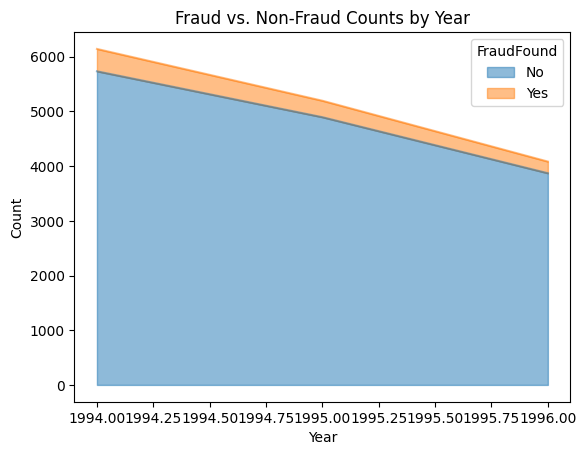

In [15]:
# 5. Draw Area Graph for Fraud vs. Non-Fraud Counts by Year
yearly_counts = df.groupby("Year")["FraudFound"].value_counts().unstack().fillna(0)
plt.figure(figsize=(10, 5))
yearly_counts.plot.area(alpha=0.5)
plt.title("Fraud vs. Non-Fraud Counts by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend(title="FraudFound")
plt.show()

Are the Data What You Expect? Are They Usable? 
- The data meet expectations for insurance fraud analysis—low fraud incidence (6%, per Homework 2) and weak correlations reflect fraud’s complex, non-linear nature, consistent with real-world datasets. With 15,420 records and no preprocessing blockers (Homework 2), the data are usable for bivariate analysis and modeling, supporting Milestone 3 goals.

Do You See Any Outliers?
- Deductible vs. FraudFound Scatterplot: Outliers are evident at "Deductible" values of 300, 500, 600, and 700, where points are sparse compared to the dense cluster at 400. Notably, fraud cases ("FraudFound" = 1) appear more frequently at higher deductibles (e.g., 600, 700), suggesting a potential fraud pattern.
- Age vs. FraudFound Scatterplot: Outliers include the 320 rows with "Age" = 0 (noted in Homework 2), mostly non-fraud ("FraudFound" = 0), and sparse points near 80, which are plausible but less common. Fraud cases are distributed across all ages, with no clear clustering.
- Pairplot: The histograms on the diagonal confirm "Age" = 0 outliers and "Deductible"’s skew toward 400, while scatterplots show no extreme deviations in other pairs (e.g., "DriverRating" vs. "Year").


Are Any Data Items Highly Correlated, Suggesting Redundancy? 
- No variables are highly correlated (|R| > 0.7). The strongest correlation is "Deductible" vs. "FraudFound" (R = 0.1329), which is moderate and not indicative of redundancy. The pairplot reinforces this—scatterplots (e.g., "Age" vs. "Deductible," "DriverRating" vs. "Year") show no strong linear patterns, meaning each variable provides unique information for fraud analysis. For example, "Age" and "Deductible" (R = -0.0086) are nearly uncorrelated, ensuring they aren’t redundant.

For the Line Plots, Do You See a Trend or Pattern Over Time? Does This Suggest Data Are Changing Over Time (Drifting)? 
- The "Average Fraud Rate by Year" line plot shows a downward trend in the mean fraud rate from ~0.066 in 1994 to ~0.052 in 1996, a ~21% relative decrease over three years. This suggests a potential drift in fraud behavior, possibly due to improved fraud detection or policy changes over time. However, with only three data points (1994–1996), this trend isn’t definitive and doesn’t invalidate comparisons across years—it indicates a need for further investigation with more temporal data. The "Fraud vs. Non-Fraud Counts by Year" area plot shows non-fraud counts slightly decreasing (~5,100 to ~4,800) while fraud counts remain stable (~300–350), supporting the fraud rate decline but not suggesting significant drift that would affect comparisons.

Can You Think of Any Confounding Variables?
- VehicleCategory: Could confound "Deductible" and "FraudFound." Higher deductibles might be associated with luxury vehicle categories (e.g., "Sport"), which could have higher fraud rates due to repair costs or owner behavior.
- Make: Might confound "Age" and "FraudFound." Homework 4 showed "Pontiac," "Toyota," and "Honda" as common makes—certain brands might correlate with driver age demographics and fraud tendencies (e.g., younger drivers with specific makes).
- Fault: Could influence "Deductible" and "FraudFound." Claims where the policyholder is at fault might involve higher deductibles and different fraud motivations compared to third-party fault claims. These variables are in the dataset and warrant deeper analysis.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

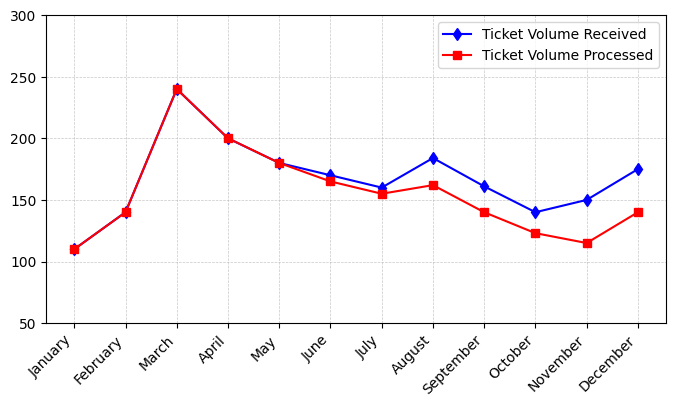

In [4]:

months = ["January", "February", "March", "April", "May", "June", 
          "July", "August", "September", "October", "November", "December"]
ticket_received = [110, 140, 240, 200, 180, 170, 160, 184, 161, 140, 150, 175]
ticket_processed = [110, 140, 240, 200, 180, 165, 155, 162, 140, 123, 115, 140]


plt.figure(figsize=(8, 4))

# Plot ticket volume received (blue line with diamond markers)
plt.plot(months, ticket_received, marker='d', linestyle='-', color='blue', label="Ticket Volume Received")

# Plot ticket volume processed (red line with square markers)
plt.plot(months, ticket_processed, marker='s', linestyle='-', color='red', label="Ticket Volume Processed")

plt.xticks(rotation=45, ha="right") 
plt.yticks(range(50, 301, 50))  
plt.ylim(50, 300)  
plt.xlabel("")  
plt.ylabel("")
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend()
plt.show()
